In [1]:
import pandas as pd
df = pd.DataFrame({
    "Size"    : [1000,1500,1800,2000,2500,3000,3500,4000,4500,5000],
    "Bedrooms": [2, 3, 3, 4, 4, 5, 5, 6, 6, 7],
    "Age"     : [10, 8, 5, 3, 7, 2, 1, 4, 6, 9],
    "Price"   : [3000000,4500000,5000000,6000000,7500000,
                 9000000,10500000,12000000,13500000,15000000]
})
print(df)

   Size  Bedrooms  Age     Price
0  1000         2   10   3000000
1  1500         3    8   4500000
2  1800         3    5   5000000
3  2000         4    3   6000000
4  2500         4    7   7500000
5  3000         5    2   9000000
6  3500         5    1  10500000
7  4000         6    4  12000000
8  4500         6    6  13500000
9  5000         7    9  15000000


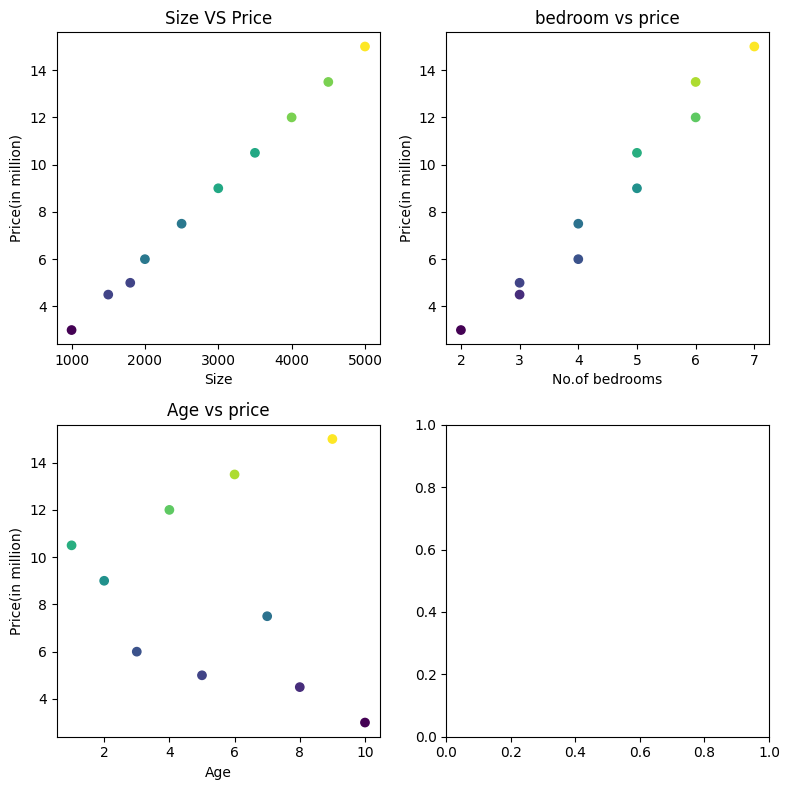

In [31]:
from matplotlib import pyplot as plt

fig,axes = plt.subplots(2,2,figsize = (8,8))

axes[0,0].scatter(df.Size,df.Price/1000000,c=df.Bedrooms)
axes[0,0].set_xlabel("Size")
axes[0,0].set_ylabel("Price(in million)")
axes[0,0].set_title("Size VS Price")
# axes[0,0].set_colorbar(label = "No. of Bedrooms")


axes[0,1].scatter(df.Bedrooms,df.Price/1000000,c=df.Size)
# axes[0,1].set_colorbar(label = "Size")
axes[0,1].set_xlabel("No.of bedrooms")
axes[0,1].set_ylabel("Price(in million)")
axes[0,1].set_title("bedroom vs price")


axes[1,0].scatter(df.Age,df.Price/1000000,c=df.Size)
# axes[1,0].set_colorbar(label = "Size")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Price(in million)")
axes[1,0].set_title("Age vs price")

plt.tight_layout()
plt.show()

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pandas as pd

df = pd.DataFrame({
    "Size"    : [1000,1500,1800,2000,2500,3000,3500,4000,4500,5000],
    "Bedrooms": [2, 3, 3, 4, 4, 5, 5, 6, 6, 7],
    "Age"     : [10, 8, 5, 3, 7, 2, 1, 4, 6, 9],
    "Price"   : [3000000,4500000,5000000,6000000,7500000,
                 9000000,10500000,12000000,13500000,15000000]
})

features = df[["Size", "Bedrooms", "Age"]]
target   = df["Price"]

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(features_train, target_train)

predictions = model.predict(features_test)
r2  = model.score(features_test, target_test)
mae = mean_absolute_error(target_test, predictions)

print(f"R² Score        : {r2:.2f}")
print(f"MAE             : ₹{mae:,.0f}")
print(f"Model Weights   : {model.coef_}")
print(f"Model Intercept : {model.intercept_:,.0f}")

print("\nActual vs Predicted:")
for actual, predicted in zip(target_test, predictions):
    print(f"Actual: ₹{actual:,.0f}  →  Predicted: ₹{predicted:,.0f}")

new_house = [[2500, 4, 5]]
price = model.predict(new_house)
print(f"\nNew House Predicted Price: ₹{price[0]:,.0f}")

R² Score        : 1.00
MAE             : ₹60,574
Model Weights   : [  2805.97481481 191593.27439009   9882.50544169]
Model Intercept : -409,846

Actual vs Predicted:
Actual: ₹13,500,000  →  Predicted: ₹13,425,896
Actual: ₹4,500,000  →  Predicted: ₹4,452,956

New House Predicted Price: ₹7,420,877


C:\Users\Amit Tiwari\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

df = pd.DataFrame({
    "Size"    : [1000,1500,1800,2000,2500,3000,3500,4000,4500,5000],
    "Bedrooms": [2, 3, 3, 4, 4, 5, 5, 6, 6, 7],
    "Age"     : [10, 8, 5, 3, 7, 2, 1, 4, 6, 9],
    "Location": ["Mumbai","Delhi","Bangalore","Mumbai","Delhi",
                 "Bangalore","Mumbai","Delhi","Bangalore","Mumbai"],
    "Price"   : [3000000,4500000,5000000,6000000,7500000,
                 9000000,10500000,12000000,13500000,15000000]
})
print(df)

   Size  Bedrooms  Age   Location     Price
0  1000         2   10     Mumbai   3000000
1  1500         3    8      Delhi   4500000
2  1800         3    5  Bangalore   5000000
3  2000         4    3     Mumbai   6000000
4  2500         4    7      Delhi   7500000
5  3000         5    2  Bangalore   9000000
6  3500         5    1     Mumbai  10500000
7  4000         6    4      Delhi  12000000
8  4500         6    6  Bangalore  13500000
9  5000         7    9     Mumbai  15000000


Location
Bangalore    9.166667e+06
Delhi        8.000000e+06
Mumbai       8.625000e+06
Name: Price, dtype: float64


<BarContainer object of 3 artists>

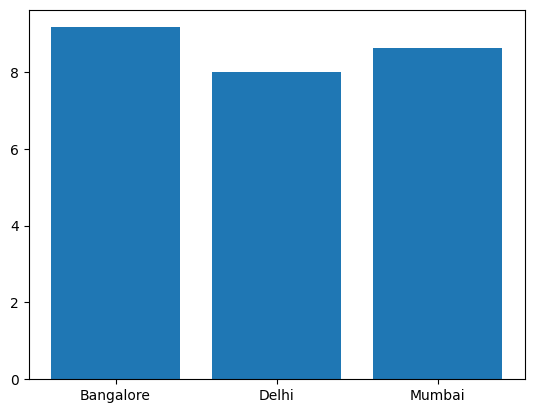

In [4]:
by_location = df.groupby("Location")["Price"].mean()
print(by_location)
plt.bar(by_location.index,by_location.values/1000000)


In [ ]:
df = pd.get_dummies(df, columns=["Location"])
print(df.columns)

Index(['Size', 'Bedrooms', 'Age', 'Price', 'Location_Bangalore',
       'Location_Delhi', 'Location_Mumbai'],
      dtype='str')


In [6]:
print(df)

   Size  Bedrooms  Age     Price  Location_Bangalore  Location_Delhi  \
0  1000         2   10   3000000               False           False   
1  1500         3    8   4500000               False            True   
2  1800         3    5   5000000                True           False   
3  2000         4    3   6000000               False           False   
4  2500         4    7   7500000               False            True   
5  3000         5    2   9000000                True           False   
6  3500         5    1  10500000               False           False   
7  4000         6    4  12000000               False            True   
8  4500         6    6  13500000                True           False   
9  5000         7    9  15000000               False           False   

   Location_Mumbai  
0             True  
1            False  
2            False  
3             True  
4            False  
5            False  
6             True  
7            False  
8            False

In [28]:
X = df[["Size","Bedrooms","Age","Location_Bangalore","Location_Mumbai","Location_Delhi"]]
Y = df["Price"]
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

model = LinearRegression().fit(X_train,Y_train)
prediction = model.predict(X_test)

mae = mean_absolute_error(Y_test,prediction)
r2 = model.score(X_test,Y_test)

print(f"R2 Score : {r2:.2f}")
print(f"MAE : {mae:,.2f}")
print(f"Model Weight : {model.coef_.round(2)}")
print(f"Intercept : {model.intercept_:.2f}")

print(f"predicted data :\n{prediction.round(2)}")
print(f"Actual data :\n{Y_test}")

price = model.predict([[1500,3,3,1,0,0]])
print(f"Price Predicted : {price[0]:,.2f}")

R2 Score : 1.00
MAE : 134,726.16
Model Weight : [   2805.96  176878.12    -307.6  -131031.45   73391.03   57640.41]
Intercept : -309706.24
predicted data :
[13245501.32  4485046.35]
Actual data :
8    13500000
1     4500000
Name: Price, dtype: int64
Price Predicted : 4,297,912.50


C:\Users\Amit Tiwari\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
